# Fig: H$\alpha$ profiles in velocity space

H$\alpha$ ($\lambda_0=6562.8$ Å) line profiles vs velocity for the production grid
(columns = mass-loss rate $\dot M_{\rm out}=2.5,5,10,20\,M_\odot$/yr; rows = wind family,
marginally-unbound over photon-tired), 45° observer (`A45P0.50`). Each profile is
continuum-normalised by a log-linear fit through line-free side-bands (baseline at 1.0;
P-Cygni absorption dips below it). Overlaid, behind the data, are two zero-baseline fit
components: a narrow Gaussian core ($e^{-v^2/2\sigma_{\rm core}^2}$, blue) and an
exponential red broad wing ($e^{-v/\sigma_{\rm wing}}$, firebrick), both from the
electron-scattering-broadened H$\alpha$. The line uses a dedicated narrow-band
`halpha_hires` restart where available, else the full-band `log_spec`; the continuum is
always taken from the full-band side-bands. Log $y$ spans the strong core and broad wings.

In [1]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
# NOTE: runs use matrix_pow ionization; photon sampling is user_bands (5 bands,
#   0.05-100 eV) for the mu family and wide for the pt family. The photon-tired family is
#   called pt_* here and in the paper (f=0.94 tiring fraction, Gamma_0=1.2128,
#   Owocki+2017 winds); its DATA still lives in repro/ptf_* on disk.
#   *** Do NOT repoint these paths at repro/pt_* -- those directories still exist and hold a
#   *** DIFFERENT, superseded Gamma_0=1.38 family. They would load silently and be wrong.
#   pt m10/m15 unconverged cells lie beyond the H recombination front (t_e collapse in
#   decoupled neutral gas; converged inside), so SPECTRA come from the *_trunc_speconly
#   extraction reruns where noted, while wind-structure tables read the parent dirs.
RUN_DIRS = {"mu_m2.5": "repro/mu_m2.5", "mu_m5": "repro/mu_m5",
                   "mu_m10": "repro/mu_m10", "mu_m15": "repro/mu_m15_trunc_speconly",
                   "pt_m2.5": "repro/ptf_m2.5", "pt_m5": "repro/ptf_m5",
                   "pt_m10": "repro/ptf_m10", "pt_m15": "repro/ptf_m15_n300_trunc_speconly"}   # both m15 columns TRUNCATED (decision 2026-08-19)   # last photon-tired col = m15 (matches gallery, 2026-08-14); parent-based halpha_hires
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

# ---- constants + run grid (cols = Mdot, rows = wind family) ----
C_KMS         = 299792.458         # km/s
C_AA_S        = 2.99792458e18      # speed of light [AA/s]
HA_LAM0       = 6562.8             # Halpha rest wavelength [AA, air]
OBS_COL       = 'A45P0.50'         # 45-deg observer column in outflow.log_spec
VLIM          = (-2900, 2900)      # km/s display window
SMOOTH_HA_KMS = 0                  # optional light boxcar (km/s) to tame MC noise
CONT_BLUE     = (-14000, -10000)   # km/s line-free side-band for the continuum fit
CONT_RED      = ( 10000,  14000)   # km/s

MDOTS  = [2.5, 5, 10, 15]
GRID_M = [
    [('mu_m2.5','mu_m2.5'), ('mu_m5','mu_m5'), ('mu_m10','mu_m10'), ('mu_m15','mu_m15')],   # marginally-unbound
    [('pt_m2.5','pt_m2.5'), ('pt_m5','pt_m5'), ('pt_m10','pt_m10'), ('pt_m15','pt_m15')],   # photon-tired
]


def log_spec_path(key):
    """Full-band log_spec path (root-aware: 'outflow' for standard runs, 'spec' for
    spectrum-only truncated reruns)."""
    base = run_path(key)
    for root in ('outflow', 'spec'):
        p = f'{base}/{root}.log_spec'
        if os.path.exists(p):
            return p
    return f'{base}/outflow.log_spec'


def _v_fl(path):
    """velocity [km/s] vs Halpha and F_lambda from a spectrum file, sorted blue->red.
    Wavelength from the full-precision `Freq.` column (the `Lambda` column is rounded
    to ~1 AA, which would collapse the velocity grid)."""
    s   = pd.read_csv(path, sep=r'\s+', comment='#')
    lam = C_AA_S / s['Freq.'].to_numpy()
    v   = C_KMS * (lam - HA_LAM0) / HA_LAM0
    fl  = s[OBS_COL].to_numpy()
    o   = np.argsort(v)
    return v[o], fl[o]


def ha_spec_path(key):
    """Prefer a dedicated halpha_hires restart for the LINE, else the full-band log_spec."""
    hi = f'{run_path(key)}/halpha_hires/outflow.log_spec'
    return (hi, 'hires') if os.path.exists(hi) else (log_spec_path(key), 'full')


def full_continuum(key, vq):
    """Halpha continuum at velocities vq, from a log-linear fit through the blue/red
    side-bands of the FULL-band spectrum (strictly positive)."""
    v, fl = _v_fl(log_spec_path(key))
    side = (((v >= CONT_BLUE[0]) & (v <= CONT_BLUE[1])) |
            ((v >= CONT_RED[0]) & (v <= CONT_RED[1]))) & (fl > 0)
    coef = np.polyfit(v[side], np.log(fl[side]), 1)
    return np.exp(np.polyval(coef, vq))


def halpha_profile(key):
    """velocity [km/s], continuum-normalised F_lambda around Halpha (continuum from the
    FULL spectrum), and the line-source kind ('hires'/'full'). Baseline sits at 1.0."""
    path, kind = ha_spec_path(key)
    v, fl = _v_fl(path)
    keep = (v > -3000) & (v < 3000)
    v, fl = v[keep], fl[keep]
    if SMOOTH_HA_KMS > 0:
        dv = np.median(np.diff(v))
        if dv > 0:
            fl = uniform_filter1d(fl, size=max(1, round(SMOOTH_HA_KMS / dv)))
    return v, fl / full_continuum(key, v), kind


# ---- fit components (each decays to zero -- no additive constant in what is plotted) ----
def _gauss_b(v, base, amp, mu, sig):                 # base used only DURING the fit ...
    return base + amp * np.exp(-0.5 * ((v - mu) / sig) ** 2)
def _gauss(v, amp, mu, sig):                         # ... and dropped when plotting
    return amp * np.exp(-0.5 * ((v - mu) / sig) ** 2)


def fit_core(v, p):
    """Narrow-core Gaussian.  A constant `base` is included DURING the fit (flux-weighted,
    sigma=1/p) only to stop the broad pedestal from widening the core; it is then folded into amp,
    so the plotted Gaussian peaks at the data and still decays to zero far away.
    The flux weighting also makes it ignore the narrow blueshifted absorption dip."""
    mu, sig = 0.0, 150.0
    popt = None
    for it in range(3):
        m = np.abs(v) < 1200 if it == 0 else np.abs(v - mu) < max(3 * sig, 250)
        vv, pp = v[m], p[m]
        if vv.size < 6:
            break
        p0 = [np.percentile(pp, 20), max(pp.max(), 1e-3), mu, sig]
        try:
            popt, _ = curve_fit(_gauss_b, vv, pp, p0=p0, sigma=1.0 / np.clip(pp, 0.3, None),
                                bounds=([0, 0, -400, 15], [np.inf, np.inf, 400, 900]), maxfev=40000)
        except Exception:
            return None
        base, amp, mu, sig = popt
    return (amp + base, mu, sig)   # fold pedestal into amplitude: peak matches data, still ->0


def fit_redwing(v, p, core, width=None):
    """Exponential A*exp(-v/v0) fit to the RED broad wing only (v beyond the core).
    width=None fits the full wing out to 2800 km/s (the default); a finite width fits
    only [v_lo, v_lo+width] — used for pt_m15, whose steep wing meets the continuum
    by ~800 km/s so a full-window fit is baseline-biased.
    Returns (log-linear coef, v_lo, v_draw_hi); model is exp(polyval(coef, v))."""
    if core is None:
        return None
    amp, mu, sig = core
    vlo = max(mu + 2.5 * sig, 300.0)
    vhi = vlo + width if width else 2800.0
    m = (v >= vlo) & (v <= vhi) & (p > 0)
    if m.sum() < 5:
        return None
    return np.polyfit(v[m], np.log(p[m]), 1), vlo, (vhi if width else 2900.0)

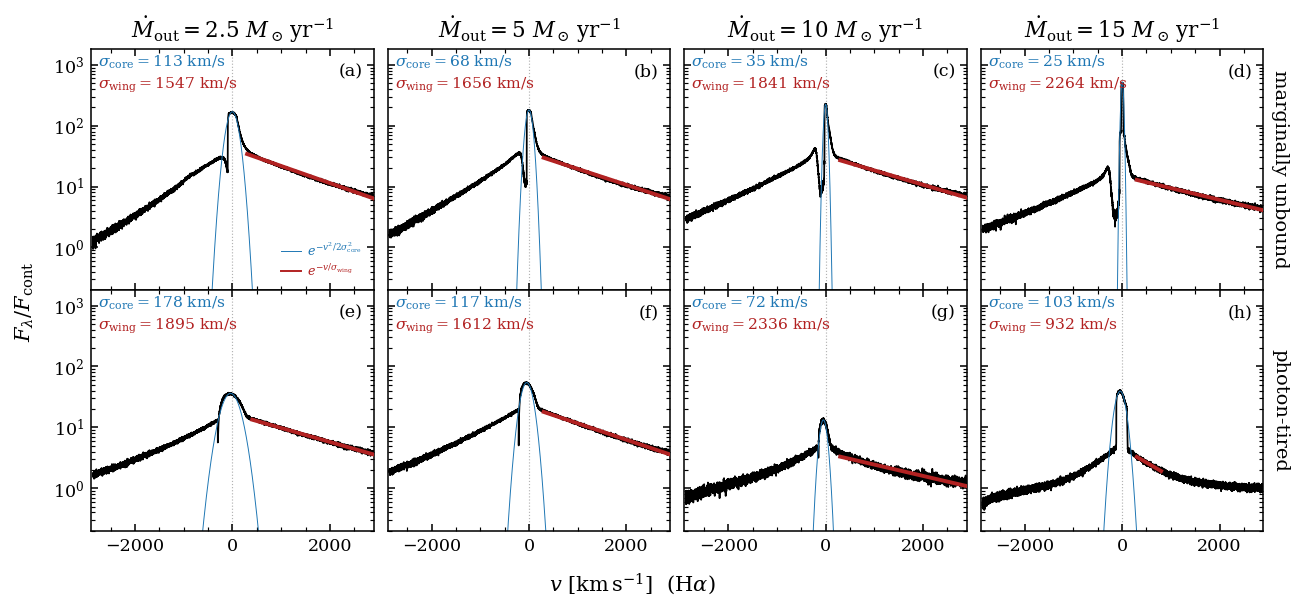

In [2]:
# ===== 2x4 Halpha profiles by Mdot (columns = Mdot, rows = wind family) =====
# Narrow-band halpha_hires line if present, else full-band; continuum from the full-band
# side-bands; Gaussian core + exponential red-wing fits overlaid behind the data.
profM  = [[halpha_profile(k) for _, k in row] for row in GRID_M]
coresM = [[fit_core(v, p) for v, p, _ in row] for row in profM]
NARROW_WING = {'pt_m15': 500.0}   # pt_m15 only: steep wing hits the continuum by ~800 km/s
wingsM = [[fit_redwing(v, p, coresM[i][j], width=NARROW_WING.get(GRID_M[i][j][1]))
           for j, (v, p, _) in enumerate(row)] for i, row in enumerate(profM)]
pmaxM  = max(np.nanmax(p[(v > VLIM[0]) & (v < VLIM[1])]) for row in profM for v, p, _ in row)

figH, axesH = plt.subplots(2, 4, figsize=(9.2, 4.3), sharex=True, sharey=True)
figH.subplots_adjust(left=0.08, right=0.99, top=0.92, bottom=0.12, hspace=0, wspace=0.05)
lettersH = iter('abcdefgh')

for i, row in enumerate(GRID_M):
    for j, (label, _) in enumerate(row):
        ax = axesH[i, j]
        v, p, kind = profM[i][j]
        ax.axvline(0.0, ls=':', lw=0.6, color='0.7', zorder=0)
        if coresM[i][j] is not None:                                 # narrow core (behind, thin)
            amp, mu, sig = coresM[i][j]
            vc = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)
            ax.plot(vc, _gauss(vc, amp, mu, sig), color='tab:blue', lw=0.5, zorder=2)
        if wingsM[i][j] is not None:                                 # red exponential wing (behind, thin)
            coef, vlo, vhiw = wingsM[i][j]
            vw = np.linspace(vlo, vhiw, 200)          # draw over the fitted range
            ax.plot(vw, np.exp(np.polyval(coef, vw)), color='firebrick', lw=2, zorder=3)
        ax.plot(v, p, color='k', lw=0.9, zorder=1)                   # data on top
        sig_core = coresM[i][j][2] if coresM[i][j] is not None else None
        sig_wing = (-1.0 / wingsM[i][j][0][0]) if wingsM[i][j] is not None else None
        _lab = []
        if sig_core is not None:
            _lab.append((0.98, rf'$\sigma_{{\rm core}}={sig_core:.0f}$ km/s', 'tab:blue'))
        if sig_wing is not None:
            _lab.append((0.89, rf'$\sigma_{{\rm wing}}={sig_wing:.0f}$ km/s', 'firebrick'))
        for _y, _t, _c in _lab:
            ax.text(0.025, _y, _t, transform=ax.transAxes, color=_c, fontsize=8, va='top', ha='left')
        if (i, j) == (0, 0):                                         # functional-form key (panel a only)
            _keys = [Line2D([0], [0], color='tab:blue', lw=0.5, ls='-', label=r'$e^{-v^2/2\sigma_{\rm core}^2}$'),
                     Line2D([0], [0], color='firebrick', lw=1.0, ls='-', label=r'$e^{-v/\sigma_{\rm wing}}$')]
            ax.legend(handles=_keys, loc='lower right', fontsize=6.5, frameon=False,
                      handlelength=1.6, handletextpad=0.5, labelspacing=0.3, borderaxespad=0.5, labelcolor='linecolor')
        ax.text(0.96, 0.94, f'({next(lettersH)})', transform=ax.transAxes, va='top', ha='right')
        if i == 0:
            ax.set_title(rf'$\dot{{M}}_{{\rm out}} = {MDOTS[j]:g}\ M_\odot\,\mathrm{{yr}}^{{-1}}$', fontsize=11)

axesH[0, 0].set(xlim=VLIM, yscale='log', ylim=(0.2, 3.6 * pmaxM))   # propagates (sharex/sharey)
axesH[0, -1].text(1.06, 0.5, 'marginally unbound', transform=axesH[0, -1].transAxes, rotation=270,
                  va='center', ha='center', color='k', fontsize=10)
axesH[1, -1].text(1.06, 0.5, 'photon-tired', transform=axesH[1, -1].transAxes, rotation=270,
                  va='center', ha='center', color='k', fontsize=10)

figH.supxlabel(r'$v\ [\mathrm{km\,s^{-1}}]$  (H$\alpha$)')
figH.supylabel(r'$F_\lambda / F_{\mathrm{cont}}$')
figH.savefig(os.path.join(FIG_DIR, 'Fig_LRD_halpha.pdf'))
figH.savefig(os.path.join(FIG_DIR, 'Fig_LRD_halpha.png'), dpi=300)
plt.show()